# JavaParser Before–After Structural Analysis (Full Scope)

This notebook extracts intrinsic AST-based measures from all **205
unique, eligible** Stack Overflow before/after histories derived from
the complete 793-row Matcha manual-validation study
(`matcha_results_2024-05-07_manual_validation_FINAL.csv`) — not just
the subset whose `Final Manual Validation` is `Agress Yes` analyzed in
[`JavaParser_Before_After_Analysis.ipynb`](JavaParser_Before_After_Analysis.ipynb).
It uses the same wrapper strategy and metric extractor as that
notebook, so results are directly comparable across scopes.

Because this scope includes recommendations judged useful, judged not
useful, and judged inconsistently across different GitHub matches,
each history carries a `validation_group` label (`ALL_ACCEPTED`,
`ALL_REJECTED`, `MIXED`) in addition to the existing Bug Fixing /
Improving Code `recommendation_group` label. This lets the analysis
check whether structural changes differ between recommendations that
were actually judged useful and ones that were not.

The measures are structural indicators, not a composite quality score.
Lower is not universally better: bug fixes can legitimately add
branches, null checks, exception handling, or resource management.

## 1. Dependencies and configuration

JavaParser Core 3.28.1 is pinned and downloaded from Maven Central. The
notebook compiles a small auditable Java extractor and uses pandas/SciPy
only for tables and paired statistics. pandas, SciPy, and matplotlib are
pinned to exact versions: an unpinned install can silently change
`scipy.stats.wilcoxon`'s internal choice between its exact and
normal-approximation p-value methods across environments, which can
shift a borderline p-value even though the underlying data and test
statistic are unchanged.

In [1]:
%pip install -q pandas==2.3.3 scipy==1.13.1 matplotlib==3.9.4

import hashlib
import json
import math
import re
import subprocess
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

You should consider upgrading via the '/Users/chaiyong/Downloads/do_not_delete/so-edit-additional-prs/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
ROOT = Path.cwd().resolve()
DATASET = ROOT / "dataset"
MANIFEST_PATH = DATASET / "snippet_pairs.csv"
MAPPING_PATH = DATASET / "study_pair_mapping.csv"
WORK_ROOT = ROOT / "work" / "javaparser_full"
RESULTS_ROOT = ROOT / "results" / "javaparser_full"
TOOLS_ROOT = ROOT / "tools"

JAVAPARSER_VERSION = "3.28.1"
JAVAPARSER_JAR = TOOLS_ROOT / f"javaparser-core-{JAVAPARSER_VERSION}.jar"
JAVAPARSER_URL = (
    "https://repo1.maven.org/maven2/com/github/javaparser/javaparser-core/"
    f"{JAVAPARSER_VERSION}/javaparser-core-{JAVAPARSER_VERSION}.jar"
)

for directory in (WORK_ROOT, RESULTS_ROOT, TOOLS_ROOT):
    directory.mkdir(parents=True, exist_ok=True)
for required in (MANIFEST_PATH, MAPPING_PATH):
    assert required.is_file(), required
if not JAVAPARSER_JAR.is_file():
    print(f"Downloading JavaParser {JAVAPARSER_VERSION}...")
    urllib.request.urlretrieve(JAVAPARSER_URL, JAVAPARSER_JAR)
print("JavaParser JAR:", JAVAPARSER_JAR)

JavaParser JAR: /Users/chaiyong/Downloads/do_not_delete/so-edit-additional-prs/before-after/tools/javaparser-core-3.28.1.jar


## 2. Load the full-scope dataset

`snippet_pairs.csv` covers every unique Stack Overflow question/code-block
history reachable from the 793 study rows, deduplicated the same way as
the scoped analysis (one independent observation per `Snippet ID`). It is
filtered here to `Status == ELIGIBLE` (both before and after snapshots
exist), and `Recommendation Types` (semicolon-joined, possibly empty) is
collapsed to a single `recommendation_group` label the same way the
scoped notebook does: a single type is kept as-is, more than one becomes
`MULTIPLE_TYPES`, and no type (a history with no accepted study row to
classify by) becomes `NO_TYPE`.

In [3]:
def classify_recommendation_group(value):
    types = [item for item in value.split(";") if item]
    if len(types) > 1:
        return "MULTIPLE_TYPES"
    if len(types) == 1:
        return types[0]
    return "NO_TYPE"

pairs = pd.read_csv(MANIFEST_PATH, dtype=str, keep_default_na=False)
pairs = pairs.loc[pairs["Status"] == "ELIGIBLE"].copy()
pairs = pairs.rename(columns={
    "Accepted Pair Count": "accepted_study_rows",
    "Validation Group": "validation_group",
})
pairs["recommendation_group"] = pairs["Recommendation Types"].map(classify_recommendation_group)

mapping = pd.read_csv(MAPPING_PATH, dtype=str, keep_default_na=False)
dataset_exclusions = mapping.loc[mapping["Dataset Status"] != "ELIGIBLE"].copy()

assert len(pairs) == 205 and pairs["Snippet ID"].is_unique
assert len(mapping) == 793 and len(dataset_exclusions) == 6
print("Scoped pairs:", len(pairs))
print("Study-row mappings:", len(mapping), "| dataset-level exclusions:", len(dataset_exclusions))
display(pairs["recommendation_group"].value_counts().rename("histories"))
display(pairs["validation_group"].value_counts().rename("histories"))

Scoped pairs: 205
Study-row mappings: 793 | dataset-level exclusions: 6


recommendation_group
Improving Code    103
NO_TYPE            80
Bug Fixing         15
MULTIPLE_TYPES      7
Name: histories, dtype: int64

validation_group
ALL_ACCEPTED    88
ALL_REJECTED    80
MIXED           37
Name: histories, dtype: int64

## 3. Create symmetric parse variants

The parser tries raw Java, class-member wrapping, and method-body wrapping.
Wrapper metadata is retained so the artificial method declaration can be
removed from the method count.

In [4]:
WRAPPERS = {
    "RAW": ("", ""),
    "CLASS_MEMBER": ("class SnippetWrapper {\n", "\n}\n"),
    "METHOD_BODY": (
        "class SnippetWrapper {\n    void snippetMethod() throws Exception {\n",
        "\n    }\n}\n",
    ),
}
MODE_ORDER = list(WRAPPERS)
input_rows = []
for mode, (prefix, suffix) in WRAPPERS.items():
    for version, source_column in (
        ("before", "Before Dataset Path"), ("after", "After Dataset Path")
    ):
        directory = WORK_ROOT / "inputs" / mode / version
        directory.mkdir(parents=True, exist_ok=True)
        for stale in directory.glob("*.java"):
            stale.unlink()
        for row in pairs.to_dict("records"):
            raw = (ROOT / row[source_column]).read_text(encoding="utf-8", errors="replace")
            target = directory / f"{row['Snippet ID']}.java"
            target.write_text(prefix + raw + suffix, encoding="utf-8")
            input_rows.append({
                "snippet_id": row["Snippet ID"], "version": version, "mode": mode,
                "input_path": str(target.resolve()),
                "artificial_methods": 1 if mode == "METHOD_BODY" else 0,
            })
input_metadata = pd.DataFrame(input_rows)
input_metadata.to_csv(WORK_ROOT / "input_metadata.csv", index=False)
print("Generated variants:", len(input_metadata))

Generated variants: 1230


## 4. Compile the AST metric extractor

Extracted measures include declarations, parameters, local variables,
branches and loops, a documented cyclomatic-complexity proxy, maximum
control-flow nesting, abrupt exits, exception handling, empty blocks, null
comparisons, and try-with-resources usage. The proxy equals one plus
decisions (`if`, loops, catches, conditional expressions, switch labels,
and boolean `&&`/`||`).

In [5]:
EXTRACTOR_SOURCE = r"""
import com.github.javaparser.*;
import com.github.javaparser.ast.*;
import com.github.javaparser.ast.body.*;
import com.github.javaparser.ast.expr.*;
import com.github.javaparser.ast.stmt.*;
import java.io.*;
import java.nio.charset.StandardCharsets;
import java.nio.file.*;
import java.util.*;
import java.util.stream.*;

public class SnippetMetricsExtractor {
  static long n(Node root, Class<? extends Node> type) {
    return root.stream().filter(type::isInstance).count();
  }
  static String q(String value) {
    return "\"" + value.replace("\"", "\"\"").replace("\r", " ").replace("\n", " ") + "\"";
  }
  static int maxControlNesting(Node root) {
    Set<Class<?>> controls = Set.of(IfStmt.class, ForStmt.class, ForEachStmt.class,
      WhileStmt.class, DoStmt.class, SwitchStmt.class, TryStmt.class, CatchClause.class);
    int max = 0;
    for (Node node : root.getChildNodesByType(Node.class)) {
      if (!controls.contains(node.getClass())) continue;
      int depth = 1;
      Optional<Node> parent = node.getParentNode();
      while (parent.isPresent()) {
        if (controls.contains(parent.get().getClass())) depth++;
        parent = parent.get().getParentNode();
      }
      max = Math.max(max, depth);
    }
    return max;
  }
  static long switchLabels(Node root) {
    return root.findAll(SwitchEntry.class).stream()
      .filter(entry -> !entry.getLabels().isEmpty()).count();
  }
  static long booleanDecisions(Node root) {
    return root.findAll(BinaryExpr.class).stream().filter(expr ->
      expr.getOperator() == BinaryExpr.Operator.AND ||
      expr.getOperator() == BinaryExpr.Operator.OR).count();
  }
  static long nullChecks(Node root) {
    return root.findAll(BinaryExpr.class).stream().filter(expr ->
      (expr.getOperator() == BinaryExpr.Operator.EQUALS ||
       expr.getOperator() == BinaryExpr.Operator.NOT_EQUALS) &&
      (expr.getLeft().isNullLiteralExpr() || expr.getRight().isNullLiteralExpr())).count();
  }
  static long localVariables(Node root) {
    return root.findAll(VariableDeclarationExpr.class).stream()
      .mapToLong(expr -> expr.getVariables().size()).sum();
  }
  static int maximumParameters(Node root) {
    return root.findAll(CallableDeclaration.class).stream()
      .mapToInt(call -> call.getParameters().size()).max().orElse(0);
  }
  static String metrics(Path path) {
    ParserConfiguration config = new ParserConfiguration()
      .setLanguageLevel(ParserConfiguration.LanguageLevel.BLEEDING_EDGE);
    JavaParser parser = new JavaParser(config);
    try {
      ParseResult<CompilationUnit> result = parser.parse(path);
      if (!result.isSuccessful() || result.getResult().isEmpty()) {
        String problem = result.getProblems().stream().map(Object::toString)
          .collect(Collectors.joining(" | "));
        return q(path.getFileName().toString()) + ",false," + q(problem);
      }
      CompilationUnit root = result.getResult().get();
      long methods = n(root, MethodDeclaration.class) + n(root, ConstructorDeclaration.class);
      long ifs=n(root,IfStmt.class), fors=n(root,ForStmt.class), foreach=n(root,ForEachStmt.class);
      long whiles=n(root,WhileStmt.class), dos=n(root,DoStmt.class), catches=n(root,CatchClause.class);
      long conditionals=n(root,ConditionalExpr.class), labels=switchLabels(root), bools=booleanDecisions(root);
      long complexity = 1 + ifs + fors + foreach + whiles + dos + catches + conditionals + labels + bools;
      long parameters = root.findAll(CallableDeclaration.class).stream()
        .mapToLong(call -> call.getParameters().size()).sum();
      long tryResources = root.findAll(TryStmt.class).stream()
        .filter(t -> !t.getResources().isEmpty()).count();
      long emptyCatches = root.findAll(CatchClause.class).stream()
        .filter(c -> c.getBody().getStatements().isEmpty()).count();
      long emptyBlocks = root.findAll(BlockStmt.class).stream()
        .filter(b -> b.getStatements().isEmpty()).count();
      long abrupt = n(root,ReturnStmt.class)+n(root,BreakStmt.class)+n(root,ContinueStmt.class)+n(root,ThrowStmt.class);
      long exceptionHandling = catches + n(root,ThrowStmt.class) + n(root,TryStmt.class);
      long[] values = {methods, parameters, maximumParameters(root), localVariables(root),
        ifs, fors+foreach+whiles+dos, n(root,SwitchStmt.class), catches, complexity,
        maxControlNesting(root), abrupt, n(root,TryStmt.class), tryResources, n(root,ThrowStmt.class),
        emptyCatches, emptyBlocks, nullChecks(root), exceptionHandling};
      return q(path.getFileName().toString()) + ",true,\"\"" +
        Arrays.stream(values).mapToObj(Long::toString).collect(Collectors.joining(",", ",", ""));
    } catch (Exception ex) {
      return q(path.getFileName().toString()) + ",false," + q(ex.toString());
    }
  }
  public static void main(String[] args) throws Exception {
    Path directory=Paths.get(args[0]), output=Paths.get(args[1]);
    List<String> header=List.of("file","parse_ok","parse_error","method_count","parameter_count",
      "max_parameters","local_variable_count","if_count","loop_count","switch_count","catch_count",
      "cyclomatic_proxy","max_control_nesting","abrupt_exit_count","try_count","try_with_resources_count",
      "throw_count","empty_catch_count","empty_block_count","null_check_count","exception_handling_count");
    List<String> lines=new ArrayList<>(); lines.add(String.join(",",header));
    try (Stream<Path> paths=Files.list(directory)) {
      paths.filter(p -> p.toString().endsWith(".java")).sorted().forEach(p -> lines.add(metrics(p)));
    }
    Files.write(output,lines,StandardCharsets.UTF_8);
  }
}
"""
extractor_dir = WORK_ROOT / "extractor"
extractor_dir.mkdir(parents=True, exist_ok=True)
extractor_source = extractor_dir / "SnippetMetricsExtractor.java"
extractor_source.write_text(EXTRACTOR_SOURCE, encoding="utf-8")
compile_result = subprocess.run(
    ["javac", "-cp", str(JAVAPARSER_JAR), str(extractor_source)],
    text=True, capture_output=True,
)
if compile_result.returncode:
    raise RuntimeError(compile_result.stdout + compile_result.stderr)
print("Compiled extractor:", extractor_dir)

Compiled extractor: /Users/chaiyong/Downloads/do_not_delete/so-edit-additional-prs/before-after/work/javaparser_full/extractor


## 5. Extract metrics and select a common parse mode

In [6]:
extracted_frames = []
classpath = f"{JAVAPARSER_JAR}:{WORK_ROOT / 'extractor'}"
for mode in MODE_ORDER:
    for version in ("before", "after"):
        input_dir = WORK_ROOT / "inputs" / mode / version
        output = WORK_ROOT / f"metrics_{mode}_{version}.csv"
        completed = subprocess.run(
            ["java", "-cp", classpath, "SnippetMetricsExtractor", str(input_dir), str(output)],
            text=True, capture_output=True,
        )
        if completed.returncode:
            raise RuntimeError(completed.stdout + completed.stderr)
        frame = pd.read_csv(output, keep_default_na=False)
        frame["snippet_id"] = frame["file"].str.removesuffix(".java")
        frame["mode"], frame["version"] = mode, version
        extracted_frames.append(frame)
extracted = pd.concat(extracted_frames, ignore_index=True)

ok = set(extracted.loc[extracted["parse_ok"], ["snippet_id", "version", "mode"]]
         .itertuples(index=False, name=None))
selected = []
for snippet_id in pairs["Snippet ID"]:
    mode = next((m for m in MODE_ORDER if (snippet_id,"before",m) in ok
                 and (snippet_id,"after",m) in ok), "")
    selected.append({"snippet_id": snippet_id, "selected_mode": mode})
selected_modes = pd.DataFrame(selected)
selected_metrics = extracted.merge(selected_modes, on="snippet_id")
selected_metrics = selected_metrics.loc[
    selected_metrics["mode"] == selected_metrics["selected_mode"]
].copy()
# parse-failure rows have fewer CSV fields than the header, so keep_default_na=False
# fills the missing metric columns with "" instead of NaN, leaving the whole column
# as object/string dtype even after filtering down to successfully parsed rows.
selected_metrics["method_count"] = pd.to_numeric(selected_metrics["method_count"])
selected_metrics.loc[selected_metrics["mode"] == "METHOD_BODY", "method_count"] -= 1

extracted.to_csv(RESULTS_ROOT / "javaparser_all_parse_attempts.csv", index=False)
display(selected_modes["selected_mode"].replace("", "NO_COMMON_MODE").value_counts())

selected_mode
RAW               113
NO_COMMON_MODE     77
METHOD_BODY         9
CLASS_MEMBER        6
Name: count, dtype: int64

## 6. Build paired metric table

In [7]:
METRICS = [
    "method_count", "parameter_count", "max_parameters", "local_variable_count",
    "if_count", "loop_count", "switch_count", "catch_count", "cyclomatic_proxy",
    "max_control_nesting", "abrupt_exit_count", "try_count", "try_with_resources_count",
    "throw_count", "empty_catch_count", "empty_block_count", "null_check_count",
    "exception_handling_count",
]
rows = []
for pair in pairs.to_dict("records"):
    snippet_id = pair["Snippet ID"]
    mode = selected_modes.loc[selected_modes["snippet_id"] == snippet_id, "selected_mode"].iloc[0]
    row = {
        "snippet_id": snippet_id, "status": "ANALYZED" if mode else "PARSE_EXCLUDED",
        "parse_mode": mode, "recommendation_group": pair["recommendation_group"],
        "validation_group": pair["validation_group"],
        "accepted_study_rows": int(pair["accepted_study_rows"]),
        "identical_before_after": pair["Identical Before After"],
    }
    for version, path_column in (("before","Before Dataset Path"),("after","After Dataset Path")):
        text = (ROOT / pair[path_column]).read_text(encoding="utf-8", errors="replace")
        no_comments = re.sub(r"/\*.*?\*/", "", text, flags=re.S)
        no_comments = re.sub(r"//.*", "", no_comments)
        row[f"{version}_code_lines"] = sum(bool(line.strip()) for line in no_comments.splitlines())
        if mode:
            record = selected_metrics.loc[(selected_metrics["snippet_id"] == snippet_id)
                                          & (selected_metrics["version"] == version)].iloc[0]
            for metric in METRICS:
                row[f"{version}_{metric}"] = int(record[metric])
    if mode:
        row["delta_code_lines"] = row["after_code_lines"] - row["before_code_lines"]
        for metric in METRICS:
            row[f"delta_{metric}"] = row[f"after_{metric}"] - row[f"before_{metric}"]
    rows.append(row)
pair_metrics = pd.DataFrame(rows)
pair_metrics.to_csv(RESULTS_ROOT / "javaparser_pair_metrics.csv", index=False)
analyzed = pair_metrics.loc[pair_metrics["status"] == "ANALYZED"].copy()
display(pair_metrics["status"].value_counts())
display(pair_metrics.head())

status
ANALYZED          128
PARSE_EXCLUDED     77
Name: count, dtype: int64

,snippet_id,status,parse_mode,recommendation_group,validation_group,accepted_study_rows,identical_before_after,before_code_lines,before_method_count,before_parameter_count,before_max_parameters,before_local_variable_count,before_if_count,before_loop_count,before_switch_count,before_catch_count,before_cyclomatic_proxy,before_max_control_nesting,before_abrupt_exit_count,before_try_count,before_try_with_resources_count,before_throw_count,before_empty_catch_count,before_empty_block_count,before_null_check_count,before_exception_handling_count,after_code_lines,after_method_count,after_parameter_count,after_max_parameters,after_local_variable_count,after_if_count,after_loop_count,after_switch_count,after_catch_count,after_cyclomatic_proxy,after_max_control_nesting,after_abrupt_exit_count,after_try_count,after_try_with_resources_count,after_throw_count,after_empty_catch_count,after_empty_block_count,after_null_check_count,after_exception_handling_count,delta_code_lines,delta_method_count,delta_parameter_count,delta_max_parameters,delta_local_variable_count,delta_if_count,delta_loop_count,delta_switch_count,delta_catch_count,delta_cyclomatic_proxy,delta_max_control_nesting,delta_abrupt_exit_count,delta_try_count,delta_try_with_resources_count,delta_throw_count,delta_empty_catch_count,delta_empty_block_count,delta_null_check_count,delta_exception_handling_count
0,so_56815_block_2,ANALYZED,RAW,Improving Code,ALL_ACCEPTED,1,NO,8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,3.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,3.0
1,so_138950_block_6,ANALYZED,RAW,NO_TYPE,ALL_REJECTED,0,NO,27,3.0,4.0,3.0,0.0,2.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,21,3.0,4.0,3.0,0.0,2.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,-6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,so_189739_block_2,ANALYZED,RAW,Improving Code,ALL_ACCEPTED,1,NO,14,2.0,3.0,2.0,3.0,1.0,1.0,0.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14,2.0,3.0,2.0,3.0,1.0,1.0,0.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,so_359634_block_2,ANALYZED,RAW,Bug Fixing,ALL_ACCEPTED,2,NO,31,1.0,1.0,1.0,3.0,3.0,1.0,0.0,1.0,9.0,2.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,46,1.0,1.0,1.0,6.0,5.0,1.0,0.0,1.0,15.0,2.0,8.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,0.0,0.0,0.0,3.0,2.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,so_453067_block_2,ANALYZED,RAW,Improving Code,MIXED,2,NO,11,1.0,1.0,1.0,3.0,1.0,1.0,0.0,0.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20,1.0,1.0,1.0,6.0,1.0,2.0,0.0,0.0,6.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,0.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,3.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## 7. Paired descriptive statistics and Wilcoxon tests

Each metric is tested independently. Apply a multiple-testing correction
before making inferential claims, and interpret added defensive constructs
contextually rather than automatically treating positive deltas as worse.

Alongside each test, a matched-pairs rank-biserial correlation is
reported as a signed effect size (after minus before): positive values
indicate the after distribution is stochastically larger, negative
values that it is stochastically smaller. It quantifies the size of a
shift, not its desirability -- an increase in null-check count is not
automatically worse than a decrease.

In [8]:
def paired_summary(frame, metric):
    before = frame[f"before_{metric}"].astype(float)
    after = frame[f"after_{metric}"].astype(float)
    delta = after - before
    nonzero = delta[delta != 0]
    if len(nonzero):
        test = stats.wilcoxon(nonzero, alternative="two-sided", method="auto")
        ranks = stats.rankdata(abs(nonzero))
        positive_ranks, negative_ranks = ranks[nonzero > 0].sum(), ranks[nonzero < 0].sum()
        rank_biserial = (positive_ranks - negative_ranks) / (positive_ranks + negative_ranks)
    else:
        test, rank_biserial = None, 0.0
    return {
        "metric": metric, "n": len(frame), "before_median": before.median(),
        "before_iqr": before.quantile(.75)-before.quantile(.25),
        "after_median": after.median(), "after_iqr": after.quantile(.75)-after.quantile(.25),
        "delta_median": delta.median(), "decreased_n": int((delta<0).sum()),
        "unchanged_n": int((delta==0).sum()), "increased_n": int((delta>0).sum()),
        "wilcoxon_statistic": test.statistic if test else math.nan,
        "wilcoxon_p": test.pvalue if test else math.nan,
        "rank_biserial_after_minus_before": rank_biserial,
    }

def holm_correct(frame):
    adjusted = pd.Series(index=frame.index, dtype=float)
    valid = frame["wilcoxon_p"].dropna().sort_values()
    running, total = 0.0, len(valid)
    for rank, (index, pvalue) in enumerate(valid.items()):
        running = max(running, min(1.0, (total - rank) * pvalue))
        adjusted.loc[index] = running
    return adjusted

summaries = pd.DataFrame([paired_summary(analyzed, m) for m in ["code_lines"] + METRICS])
summaries["holm_p"] = holm_correct(summaries)
summaries.to_csv(RESULTS_ROOT / "javaparser_statistical_summary.csv", index=False)
display(summaries)

subgroup_rows = []
single_type = analyzed.loc[analyzed["recommendation_group"].isin(
    ["Bug Fixing", "Improving Code"]
)]
for group, frame in single_type.groupby("recommendation_group"):
    for metric in ["code_lines"] + METRICS:
        subgroup_rows.append({"recommendation_group": group,
                              **paired_summary(frame, metric)})
subgroup_summaries = pd.DataFrame(subgroup_rows)
subgroup_summaries.to_csv(
    RESULTS_ROOT / "javaparser_recommendation_subgroups.csv", index=False
)
print("Single-type subgroup rows:", len(single_type))
print("MULTIPLE_TYPES/NO_TYPE histories excluded:",
      (~analyzed["recommendation_group"].isin(["Bug Fixing", "Improving Code"])).sum())

,metric,n,before_median,before_iqr,after_median,after_iqr,delta_median,decreased_n,unchanged_n,increased_n,wilcoxon_statistic,wilcoxon_p,rank_biserial_after_minus_before,holm_p
0,code_lines,128,22.0,25.75,23.0,30.25,0.0,34,31,63,1575.0,0.003862,0.337261,0.069517
1,method_count,128,2.0,2.00,2.0,2.25,0.0,10,92,26,192.0,0.026031,0.423423,0.405612
2,parameter_count,128,2.0,3.00,2.0,3.00,0.0,9,102,17,88.0,0.025351,0.498575,0.405612
3,max_parameters,128,2.0,1.00,2.0,1.00,0.0,6,115,7,34.5,0.497314,0.241758,1.000000
4,local_variable_count,128,3.0,5.00,3.0,5.00,0.0,10,91,27,183.5,0.010562,0.477952,0.179553
5,if_count,128,1.0,2.25,1.0,3.00,0.0,11,103,14,136.5,0.507704,0.160000,1.000000
6,loop_count,128,0.0,1.00,0.0,1.00,0.0,1,121,6,2.5,0.078125,0.821429,0.781250
7,switch_count,128,0.0,0.00,0.0,0.00,0.0,0,128,0,NaN,NaN,0.000000,NaN
8,catch_count,128,0.0,1.00,0.0,1.00,0.0,3,117,8,15.0,0.123047,0.545455,1.000000
9,cyclomatic_proxy,128,3.0,3.25,3.0,4.00,0.0,13,88,27,247.0,0.027836,0.397561,0.405612


Single-type subgroup rows: 77
MULTIPLE_TYPES/NO_TYPE histories excluded: 51


## 8. Validation-outcome subgroup analysis

This dimension is unique to the full-scope analysis: `validation_group`
reflects whether the recommendation was judged useful across *all* of
its GitHub matches (`ALL_ACCEPTED`), useful in *none* of them
(`ALL_REJECTED`), or useful in some but not others (`MIXED`). If
structural changes are genuinely tied to recommendation quality, a
plausible (though not guaranteed) expectation is that `ALL_ACCEPTED`
histories show more/different change than `ALL_REJECTED` ones -- this
section checks that without assuming it.

In [9]:
validation_rows = []
for group, frame in analyzed.groupby("validation_group"):
    for metric in ["code_lines"] + METRICS:
        validation_rows.append({"validation_group": group, **paired_summary(frame, metric)})
validation_summaries = pd.DataFrame(validation_rows)
validation_summaries.to_csv(
    RESULTS_ROOT / "javaparser_validation_group_subgroups.csv", index=False
)
display(analyzed["validation_group"].value_counts().rename("histories"))
display(validation_summaries.loc[validation_summaries["metric"] == "code_lines"])

validation_group
ALL_ACCEPTED    59
ALL_REJECTED    48
MIXED           21
Name: histories, dtype: int64

,validation_group,metric,n,before_median,before_iqr,after_median,after_iqr,delta_median,decreased_n,unchanged_n,increased_n,wilcoxon_statistic,wilcoxon_p,rank_biserial_after_minus_before
0,ALL_ACCEPTED,code_lines,59,21.0,22.00,22.0,21.50,1.0,14,12,33,316.5,0.008225,0.438830
19,ALL_REJECTED,code_lines,48,28.5,43.25,32.5,50.75,0.0,15,12,21,237.0,0.134775,0.288288
38,MIXED,code_lines,21,19.0,10.00,18.0,15.00,0.0,5,7,9,44.0,0.625732,0.161905


## 9. Export coverage, plots, and reproducibility metadata

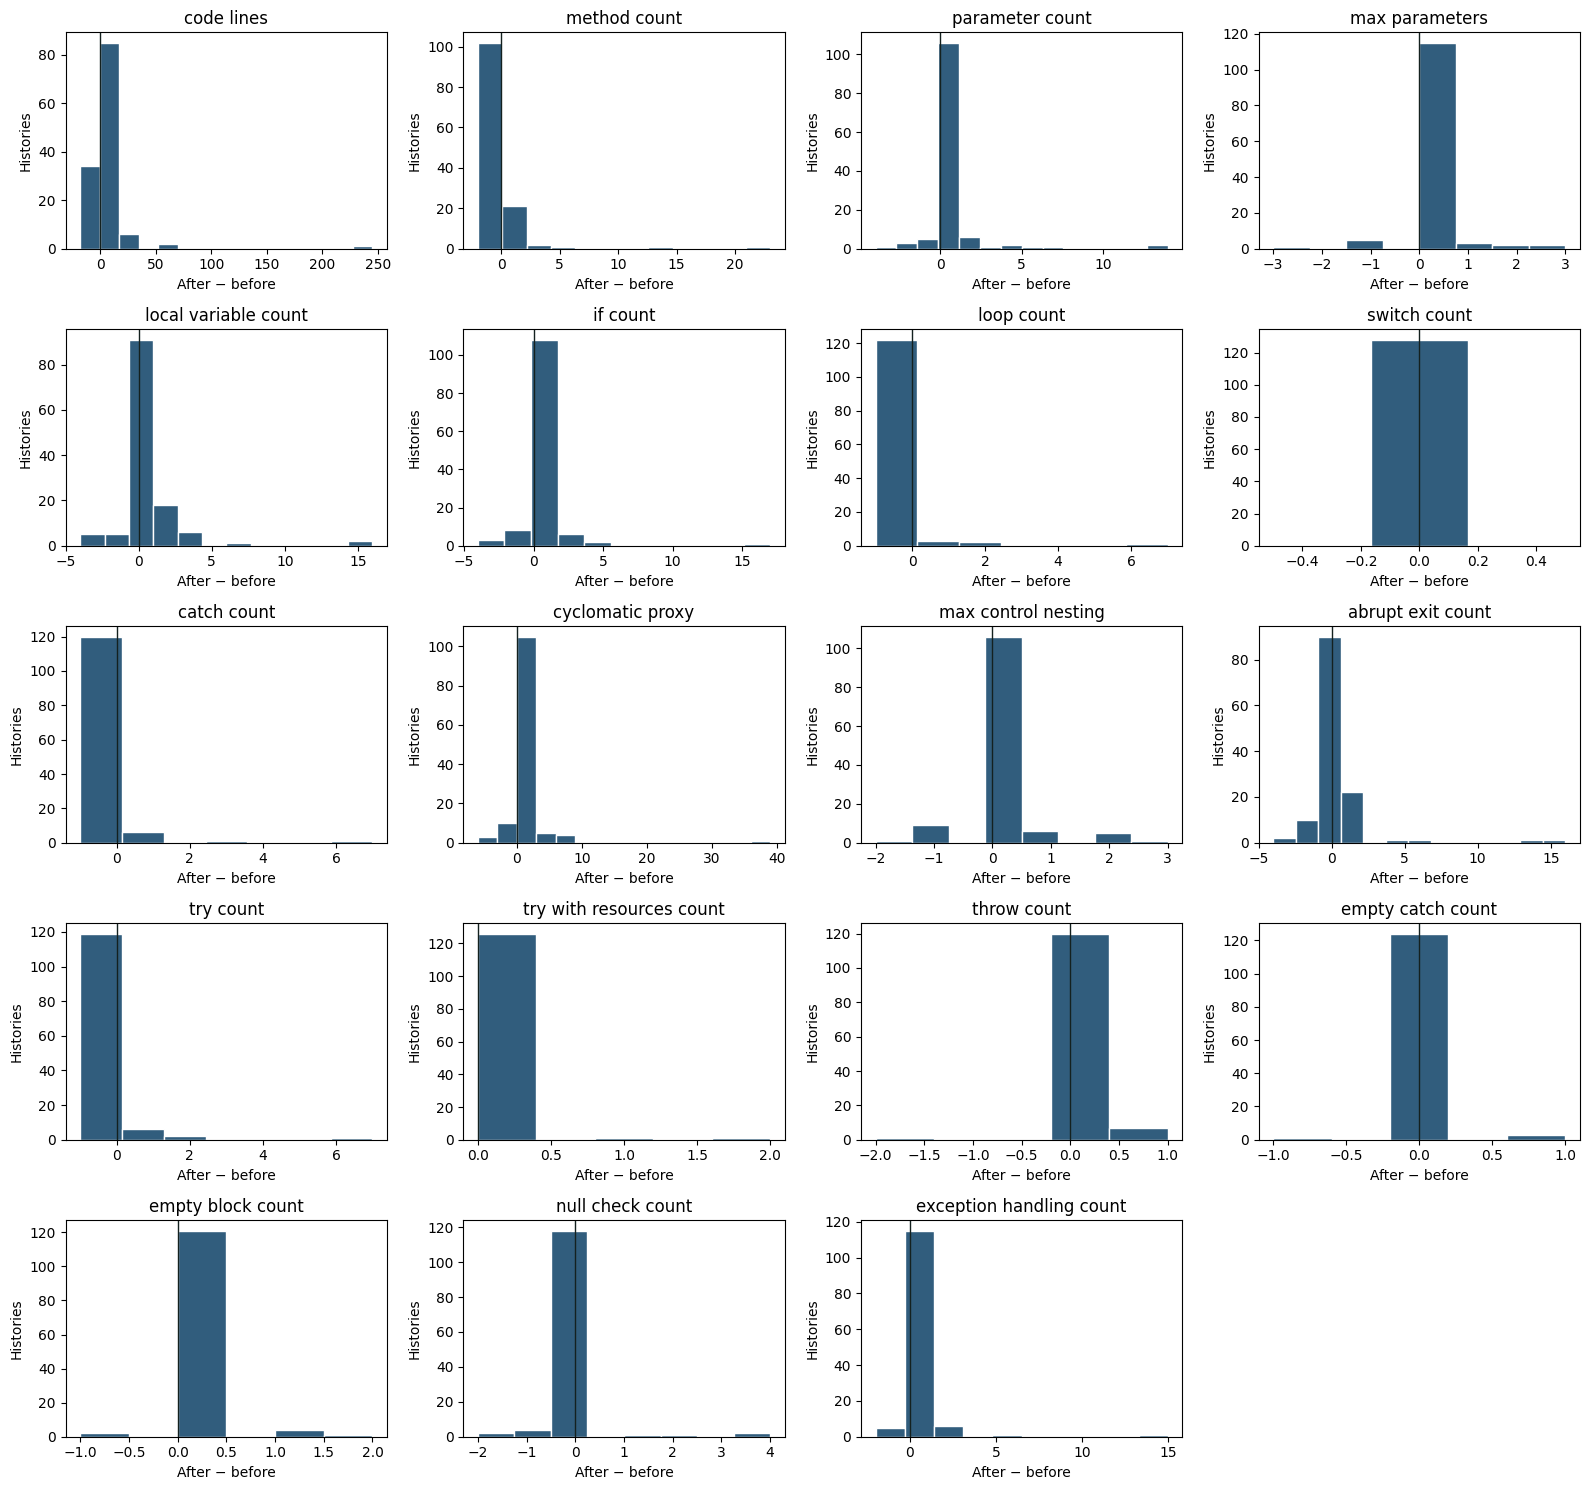

,status,parse_mode,histories
0,ANALYZED,CLASS_MEMBER,6
1,ANALYZED,METHOD_BODY,9
2,ANALYZED,RAW,113
3,PARSE_EXCLUDED,,77


{
  "javaparser_version": "3.28.1",
  "manual_validation_filter": "None (full 793-recommendation scope)",
  "scoped_pairs": 205,
  "analyzed_pairs": 128,
  "parse_excluded_pairs": 77,
  "identical_pairs": 12,
  "study_row_mappings": 793,
  "dataset_level_exclusions": 6,
  "extractor_sha256": "5ae80000cb09e1b7a131de5dd8b8a7faee27dd90fadeefe6dd4f0efafd89ea9c",
  "jar_sha256": "113742383cca4a46931008a961fbea54b2aa3a49ce8f0c54110930eac65f1876"
}
Results written to: /Users/chaiyong/Downloads/do_not_delete/so-edit-additional-prs/before-after/results/javaparser_full


In [10]:
coverage = pair_metrics.groupby(["status","parse_mode"], dropna=False).size().rename(
    "histories"
).reset_index()
coverage.to_csv(RESULTS_ROOT / "javaparser_parse_coverage.csv", index=False)
dataset_exclusions.to_csv(
    RESULTS_ROOT / "javaparser_dataset_exclusions.csv", index=False
)

plot_metrics = ["code_lines"] + METRICS
n_cols = 4
n_rows = math.ceil(len(plot_metrics) / n_cols)
figure, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
for axis, metric in zip(axes.flat, plot_metrics):
    values = analyzed[f"delta_{metric}"]
    axis.hist(values, bins=max(3, min(15, values.nunique()+2)), color="#315d7d", edgecolor="white")
    axis.axvline(0, color="#14211f", linewidth=1)
    axis.set_title(metric.replace("_", " "))
    axis.set_xlabel("After − before")
    axis.set_ylabel("Histories")
for unused_axis in axes.flat[len(plot_metrics):]:
    unused_axis.set_visible(False)
figure.tight_layout()
figure.savefig(RESULTS_ROOT / "javaparser_metric_deltas.png", dpi=180, bbox_inches="tight")
plt.show()

summary = {
    "javaparser_version": JAVAPARSER_VERSION,
    "manual_validation_filter": "None (full 793-recommendation scope)",
    "scoped_pairs": int(len(pairs)),
    "analyzed_pairs": int(len(analyzed)),
    "parse_excluded_pairs": int((pair_metrics["status"] == "PARSE_EXCLUDED").sum()),
    "identical_pairs": int((pairs["Identical Before After"] == "YES").sum()),
    "study_row_mappings": int(len(mapping)),
    "dataset_level_exclusions": int(len(dataset_exclusions)),
    "extractor_sha256": hashlib.sha256(EXTRACTOR_SOURCE.encode()).hexdigest(),
    "jar_sha256": hashlib.sha256(JAVAPARSER_JAR.read_bytes()).hexdigest(),
}
(RESULTS_ROOT / "javaparser_run_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)
display(coverage)
print(json.dumps(summary, indent=2))
print("Results written to:", RESULTS_ROOT)

## Interpretation checklist

- Do not collapse heterogeneous metrics into one opaque quality score.
- Report parsing coverage and the wrapper mode used for each pair.
- Apply Holm correction across metric-level significance tests (`holm_p`),
  and read the paired rank-biserial effect size alongside each p-value.
- This full scope mixes accepted, rejected, and mixed-validation
  recommendations; always check `validation_group` before generalizing
  a finding to "useful recommendations."
- Interpret increases in null checks, catches, throws, and resource handling
  as potentially beneficial when they implement defensive behavior.
- Manually inspect influential outliers and a random sample of parsed pairs.
- Treat the cyclomatic value as a documented proxy, not a tool-standard
  cyclomatic-complexity implementation.